<a href="https://colab.research.google.com/github/Baasmaala/road-safety-explorer/blob/osama/notebooks/02_pca_anomaly_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ============================================================
# SETUP CELL — run this first every session
# ============================================================
import os, sys, subprocess

REPO_URL  = "https://github.com/Baasmaala/road-safety-explorer.git"
REPO_NAME = "road-safety-explorer"
BRANCH    = "osama"

# Clone if not already cloned, otherwise pull latest
if not os.path.exists(REPO_NAME):
    print(f"Cloning {REPO_NAME}...")
    subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL], check=True)
else:
    print(f"Repo already cloned — pulling latest from {BRANCH}...")
    subprocess.run(["git", "-C", REPO_NAME, "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", REPO_NAME, "checkout", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_NAME, "pull", "origin", BRANCH], check=True)

# Move into the repo so all paths like data/raw/... just work
os.chdir(REPO_NAME)
print(f"\n Working directory: {os.getcwd()}")
print(f" On branch: {BRANCH}")
print(f" Files available:")
subprocess.run(["ls", "-la", "data/raw/"])

Cloning road-safety-explorer...

 Working directory: /content/road-safety-explorer/road-safety-explorer/road-safety-explorer
 On branch: osama
 Files available:


CompletedProcess(args=['ls', '-la', 'data/raw/'], returncode=0)

In [4]:
with open('README.md', 'r') as f:
    readme_text = f.read()

print("--- README.md Content ---")
print(readme_text)

--- README.md Content ---
# Road-Safety-Explorer
## Data Sources

This project uses two real, publicly available datasets. Both are committed to the repo at `data/raw/` so the analysis runs without any external downloads.

### 1. WHO Global Status Report on Road Safety 2023

**Source:** World Health Organization
**Direct link:** [WHO road safety indicators (XLSX)](https://cdn.who.int/media/docs/default-source/documents/health-topics/road-traffic-injuries/gsrrs23-indicators-for-participating-countries-or-territories.xlsx?sfvrsn=88035adb_3)
**File in repo:** `data/raw/gsrrs23-indicators-for-participating-countries-or-territories.xlsx`
**Format:** Excel spreadsheet, 173 rows × 228 columns
**License:** CC BY-NC-SA 3.0 IGO

**What it contains:**
The WHO Global Status Report on Road Safety is published every few years and is the most comprehensive country-level road safety dataset available. The 2023 edition covers 171 participating countries and territories across 228 indicators including:


### Task: Notebook 02 — PCA & Anomaly Detection
Based on the README and your branch, I will help you set up the environment for the PCA and Anomaly Detection notebook.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Path from README
file_path = 'data/raw/gsrrs23-indicators-for-participating-countries-or-territories.xlsx'

try:
    # Reloading with the second row as the header to get clean column names
    df = pd.read_excel(file_path, header=1)

    # Basic cleaning: Remove any entirely empty columns/rows
    df = df.dropna(how='all', axis=0).dropna(how='all', axis=1)

    print("Dataset re-loaded and cleaned!")
    print(f"Shape: {df.shape}")
    display(df.head())
except Exception as e:
    print(f"Error: {e}")

Dataset re-loaded and cleaned!
Shape: (172, 226)


,WHO status,ISO_3 country name,Country name,Population,Income group,WHO Region,GRSSR participation 2009,GRSSR participation 2013,GRSSR participation 2015,GRSSR participation 2018,...,Year WHO-estimated road traffic fatalities (Update),2010 WHO-estimated road traffic fatalities (update),2010 Lower bound WHO-estimated road traffic fatalities (update),2010 Upper bound WHO-estimated road traffic fatalities (update),2010 WHO-estimated rate per 100 000 population (update),Year WHO-estimated road traffic fatalities (Update).1,2016 WHO-estimated road traffic fatalities (update),2016 Lower bound WHO-estimated road traffic fatalities (update),2016 Upper bound WHO-estimated road traffic fatalities (update),2016 WHO-estimated rate per 100 000 population (update)
0,Member State,AFG,Afghanistan,40099462,Low income,Eastern Mediterranean Region,2009.0,2013.0,2015.0,2018.0,...,2010,5546.0,4764.0,6328.0,19.7,2016,7106.0,6228.0,7984.0,20.5
1,Member State,ALB,Albania,2854710,Upper middle income,European Region,2009.0,2013.0,2015.0,2018.0,...,2010,388.0,364.0,412.0,13.3,2016,370.0,344.0,395.0,12.8
2,Member State,DZA,Algeria,44177969,Lower middle income,African Region,NaN,NaN,2015.0,NaN,...,2010,8039.0,7231.0,8848.0,22.4,2016,8536.0,7558.0,9514.0,21.2
3,Member State,ATG,Antigua and Barbuda,93219,High income,Region of the Americas,NaN,NaN,2015.0,2018.0,...,2010,5.0,5.0,5.0,5.8,2016,8.0,7.0,9.0,8.8
4,Member State,ARG,Argentina,45276780,Upper middle income,Region of the Americas,2009.0,2013.0,2015.0,2018.0,...,2010,5252.0,4976.0,5528.0,12.8,2016,5755.0,5435.0,6075.0,13.2


In [7]:
# Select numeric columns and handle missing values for PCA
# We'll drop columns with too many missing values and impute the rest

numeric_df = df.select_dtypes(include=[np.number])

# Threshold: Keep columns with less than 30% missing values
threshold = 0.3 * len(numeric_df)
numeric_df = numeric_df.dropna(thresh=len(numeric_df) - threshold, axis=1)

# Simple imputation with median for remaining NaNs
numeric_df_imputed = numeric_df.fillna(numeric_df.median())

# Scale the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numeric_df_imputed)

print(f"Original numeric columns: {df.select_dtypes(include=[np.number]).shape[1]}")
print(f"Columns after dropping high-null features: {numeric_df_imputed.shape[1]}")
print("Data scaled and ready for PCA.")

Original numeric columns: 95
Columns after dropping high-null features: 40
Data scaled and ready for PCA.


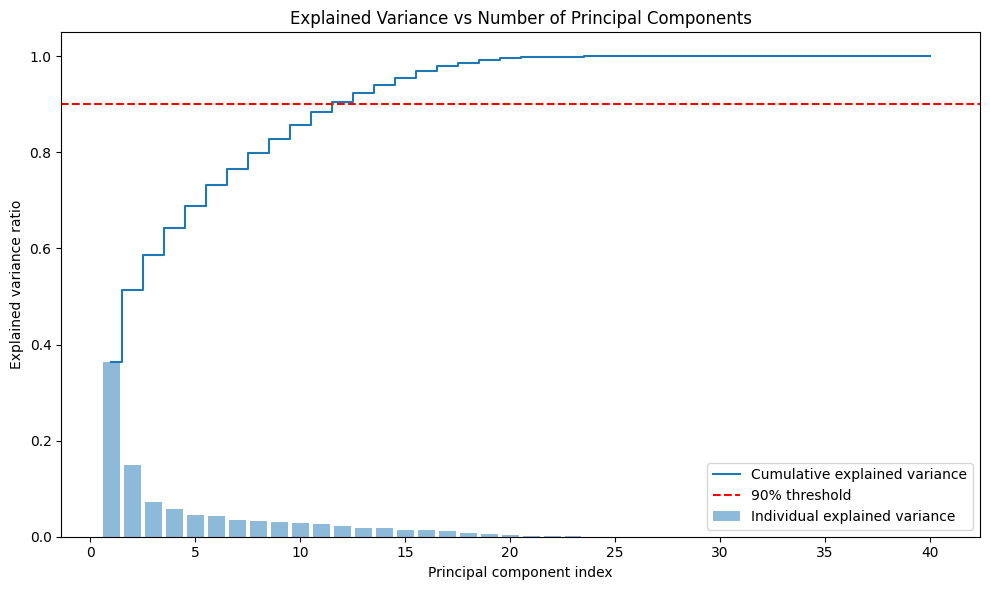

Number of components to explain 90% variance: 12


In [8]:
# Initialize PCA
pca = PCA()
pca_features = pca.fit_transform(scaled_features)

# Calculate explained variance
exp_var_pca = pca.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

# Visualize the explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var_pca)+1), exp_var_pca, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(cum_sum_eigenvalues)+1), cum_sum_eigenvalues, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Explained Variance vs Number of Principal Components')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% threshold')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

print(f"Number of components to explain 90% variance: {np.argmax(cum_sum_eigenvalues >= 0.9) + 1}")

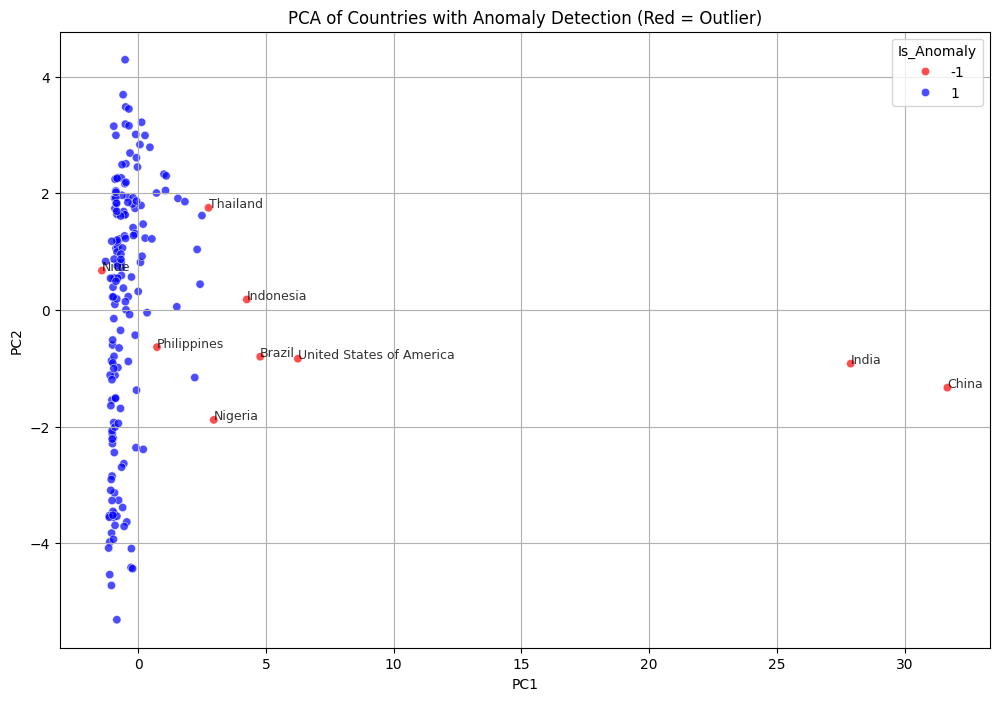

Anomalous Countries detected:
['Brazil', 'China', 'India', 'Indonesia', 'Nigeria', 'Niue', 'Philippines', 'Thailand', 'United States of America']


In [9]:
from sklearn.ensemble import IsolationForest

# 1. Project into 2D for visualization
pca_2d = PCA(n_components=2)
coords = pca_2d.fit_transform(scaled_features)

# 2. Anomaly Detection (Isolation Forest)
# contamination=0.05 assumes roughly 5% of countries might be outliers
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomalies = iso_forest.fit_predict(scaled_features)

# Create a results dataframe
results_df = pd.DataFrame({
    'Country': df['Country name'],
    'PC1': coords[:, 0],
    'PC2': coords[:, 1],
    'Is_Anomaly': anomalies
})

# 3. Plotting
plt.figure(figsize=(12, 8))
sns.scatterplot(data=results_df, x='PC1', y='PC2', hue='Is_Anomaly', palette={1: 'blue', -1: 'red'}, alpha=0.7)

# Label the anomalies
for i in range(len(results_df)):
    if results_df.iloc[i]['Is_Anomaly'] == -1:
        plt.annotate(results_df.iloc[i]['Country'], (results_df.iloc[i]['PC1'], results_df.iloc[i]['PC2']), fontsize=9, alpha=0.8)

plt.title('PCA of Countries with Anomaly Detection (Red = Outlier)')
plt.grid(True)
plt.show()

print("Anomalous Countries detected:")
print(results_df[results_df['Is_Anomaly'] == -1]['Country'].tolist())

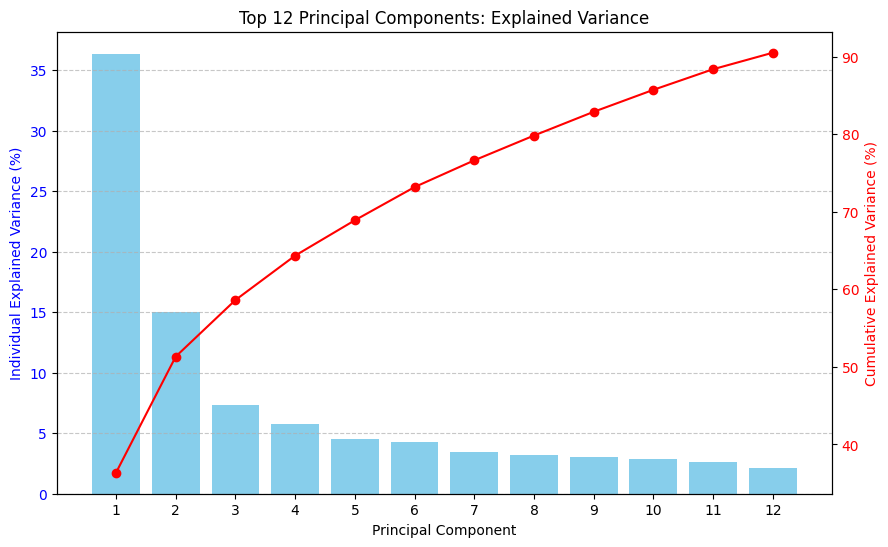

PC1: 36.35% (Cumulative: 36.35%)
PC2: 14.98% (Cumulative: 51.33%)
PC3: 7.29% (Cumulative: 58.62%)
PC4: 5.73% (Cumulative: 64.35%)
PC5: 4.56% (Cumulative: 68.90%)
PC6: 4.28% (Cumulative: 73.18%)
PC7: 3.45% (Cumulative: 76.63%)
PC8: 3.20% (Cumulative: 79.83%)
PC9: 3.06% (Cumulative: 82.89%)
PC10: 2.83% (Cumulative: 85.72%)
PC11: 2.66% (Cumulative: 88.38%)
PC12: 2.13% (Cumulative: 90.51%)


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Number of components to visualize
n_comps = 12

# Extract variance ratios
ind_var = exp_var_pca[:n_comps] * 100
cum_var = cum_sum_eigenvalues[:n_comps] * 100

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for individual variance
ax1.bar(range(1, n_comps + 1), ind_var, color='skyblue', label='Individual Variance (%)')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Individual Explained Variance (%)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(range(1, n_comps + 1))

# Line chart for cumulative variance
ax2 = ax1.twinx()
ax2.plot(range(1, n_comps + 1), cum_var, color='red', marker='o', label='Cumulative Variance (%)')
ax2.set_ylabel('Cumulative Explained Variance (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Top 12 Principal Components: Explained Variance')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

for i in range(n_comps):
    print(f"PC{i+1}: {ind_var[i]:.2f}% (Cumulative: {cum_var[i]:.2f}%)")

### Feature Importance (Loadings) for PC1 and PC2
We will now examine which original indicators contribute most to the first two principal components to explain the positioning of the anomalies.

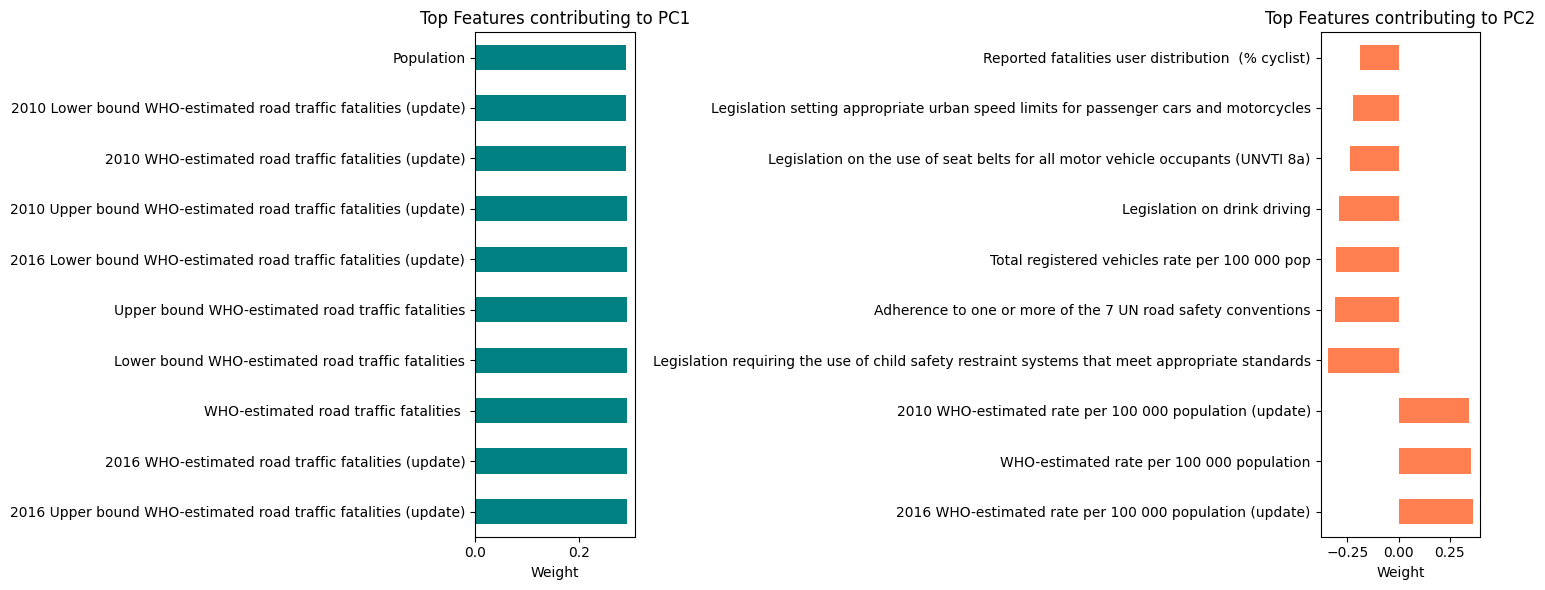

Interpretation:
PC1 is primarily driven by: 2016 Upper bound WHO-estimated road traffic fatalities (update), 2016 WHO-estimated road traffic fatalities (update), WHO-estimated road traffic fatalities 
PC2 is primarily driven by: 2016 WHO-estimated rate per 100 000 population (update), WHO-estimated rate per 100 000 population, 2010 WHO-estimated rate per 100 000 population (update)


In [11]:
import pandas as pd

# Create a DataFrame for the loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca.components_))],
    index=numeric_df_imputed.columns
)

# Get top 10 features for PC1 and PC2 by absolute weight
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(10)
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot PC1 Loadings
loadings.loc[top_pc1.index, 'PC1'].plot(kind='barh', ax=ax1, color='teal')
ax1.set_title('Top Features contributing to PC1')
ax1.set_xlabel('Weight')

# Plot PC2 Loadings
loadings.loc[top_pc2.index, 'PC2'].plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Top Features contributing to PC2')
ax2.set_xlabel('Weight')

plt.tight_layout()
plt.show()

print("Interpretation:")
print(f"PC1 is primarily driven by: {', '.join(top_pc1.index[:3].tolist())}")
print(f"PC2 is primarily driven by: {', '.join(top_pc2.index[:3].tolist())}")

### Loadings Heatmap (PC1, PC2, PC3)
This heatmap displays the relative weights of each feature across the first three principal components. Darker colors (positive or negative) indicate a stronger influence.

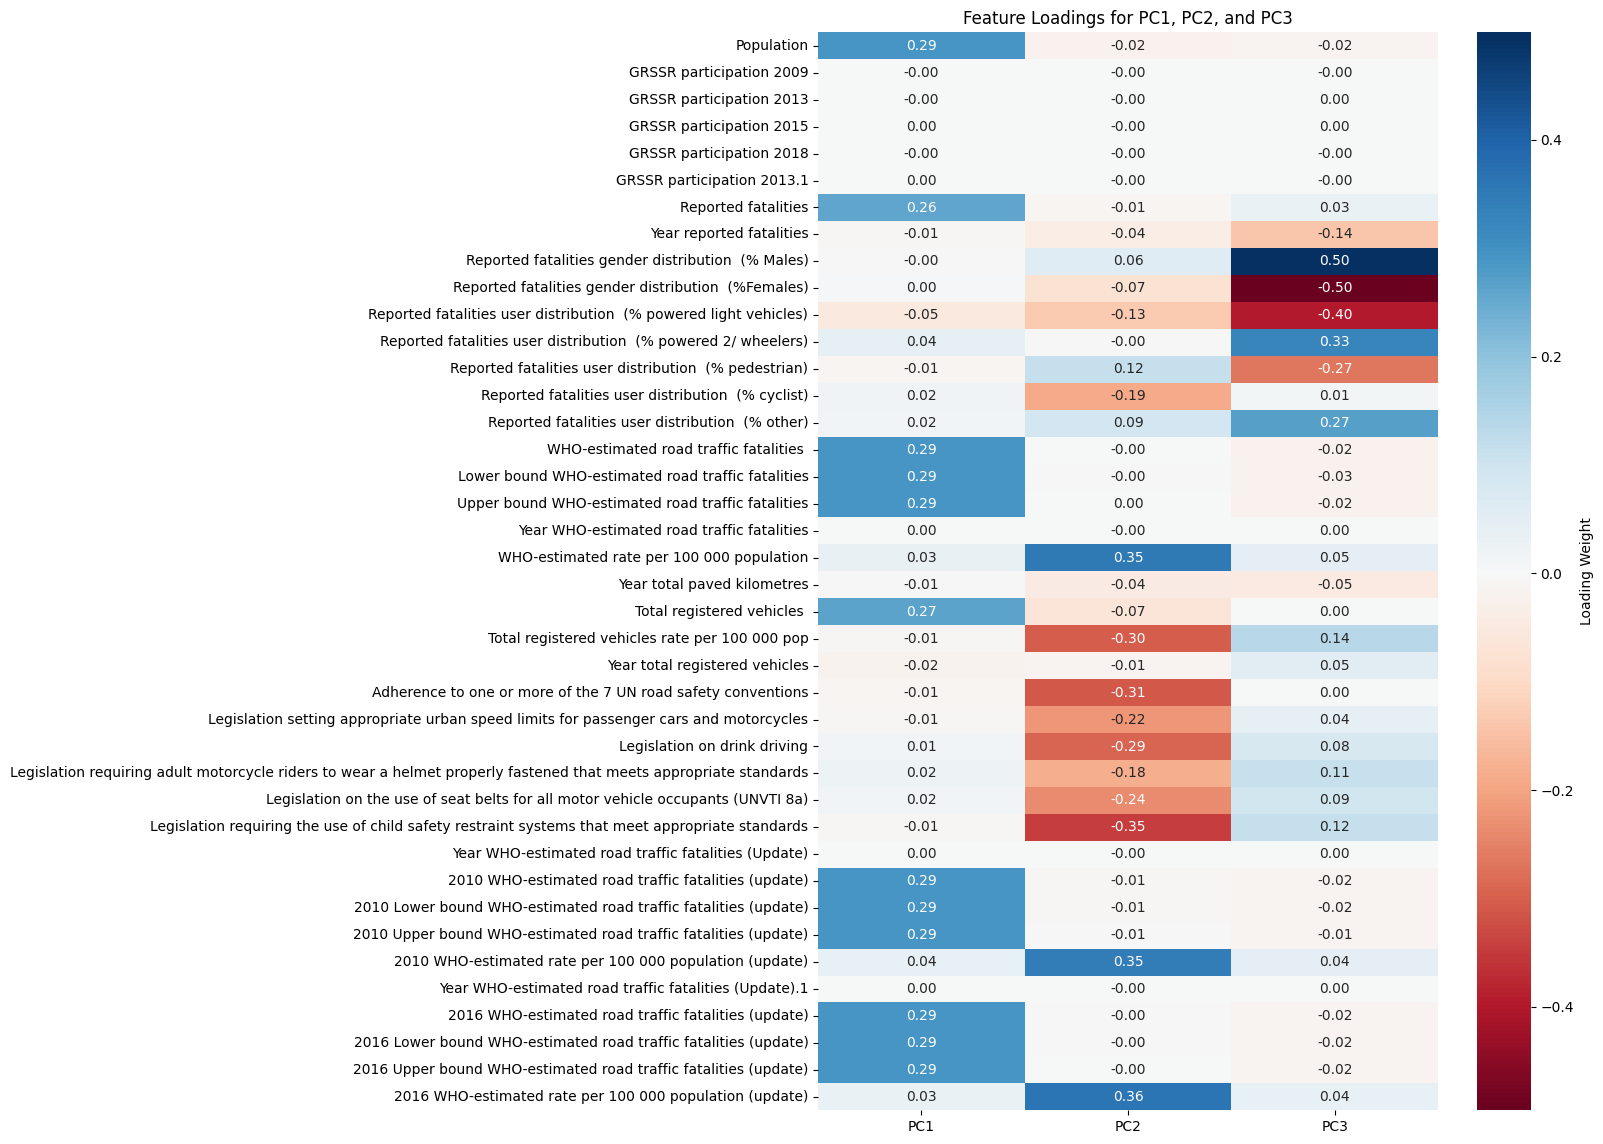

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare the loadings data for the first 3 components
heatmap_data = loadings[['PC1', 'PC2', 'PC3']]

# Increase figure height to ensure all 40 features are legible
plt.figure(figsize=(10, 14))
sns.heatmap(heatmap_data, annot=True, cmap='RdBu', center=0, fmt='.2f', cbar_kws={'label': 'Loading Weight'})

plt.title('Feature Loadings for PC1, PC2, and PC3')
plt.show()

### Explained Variance Series
Creating a labeled pandas Series for the explained variance ratios of the first 12 components.

In [13]:
# Create a Series for the explained variance of the top 12 components
variance_series = pd.Series(
    exp_var_pca[:12] * 100,
    index=[f'PC{i+1}' for i in range(12)],
    name='Explained Variance (%)'
)

print("Explained Variance Series (Top 12 Components):")
display(variance_series)

Explained Variance Series (Top 12 Components):


,Explained Variance (%)
PC1,36.349639
PC2,14.978365
PC3,7.290178
PC4,5.727189
PC5,4.558283
PC6,4.277524
PC7,3.450147
PC8,3.196529
PC9,3.062346
PC10,2.833996
